In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load data
file_path = 'PID11_SESSION1.csv'
df = pd.read_csv(file_path)

# This adds a session counter for each unique Maze_ID, (The "+ 1" was added to let it start from 1 instead of 0)
df["session"] = df.groupby("Maze_ID").cumcount() + 1

# This makes unique Maze IDs, so that session numbers are plotted for each unique Maze_ID
unique_mazes =  sorted(df["Maze_ID"].unique())

# Set up the plot structure
plt.figure(figsize=(7, 5))

# Plots time taken for each session for each unique Maze_ID
for maze in unique_mazes:
    maze_data = df[df["Maze_ID"] == maze]

    plt.plot(
        maze_data["session"],   # X-axis: session number
        maze_data["time_taken"],# Y-axis: time taken
        label=f"Maze {maze}",   # Legend label
        marker="o",             # Adds dot
        markersize=10,          # Dot size
        linewidth=2,            # Line width
        alpha=0.8,              # Transparency of lines and dots
    )

# Layout and labels
plt.title("Time Taken Across 5 Sessions by Maze ID", fontsize=14, pad=15)
plt.xlabel("Session Number", fontsize=12)
plt.ylabel("Time Taken (seconds)", fontsize=12)

# Makes the X-axis only shows whole numbers
plt.xticks(df["session"].unique())

# Adds grid lines, legend and tight layout for better spacing
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Maze IDs", bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()

# Show plot
plt.show()


In [6]:
import os
import matplotlib.pyplot as plt
import pandas as pd


class SessionTime:

    def __init__(self, file_paths):
        # Accept either a single path (str) or a list/tuple of paths
        if isinstance(file_paths, str):
            file_paths = [file_paths]

        self.file_paths = file_paths
        self.dataframes = {}   # label (filename without extension) -> dataframe
        self.df = None         # all files combined into one dataframe
        self._load_data()

    def _load_data(self):
        all_dfs = []

        for path in self.file_paths:
            df = pd.read_csv(path)
            df["session"] = df.groupby("Maze_ID").cumcount() + 1

            label = os.path.splitext(os.path.basename(path))[0]
            df["source_file"] = label

            self.dataframes[label] = df
            all_dfs.append(df)

        self.df = pd.concat(all_dfs, ignore_index=True)

    def _plot(self, df, title, output_file=None):
        """Shared plotting logic used by both plot_each_file and plot_combined."""
        if df is None or df.empty:
            print("No data available to plot.")
            return

        plt.figure(figsize=(10, 6))
        unique_mazes = sorted(df["Maze_ID"].unique())

        for maze in unique_mazes:
            maze_data = df[df["Maze_ID"] == maze]
            plt.plot(
                maze_data["session"],
                maze_data["time_taken"],
                label=f"Maze {maze}",
                marker="o",
                markersize=10,
                linewidth=2,
                alpha=0.8,
            )

        plt.title(title, fontsize=14, pad=15)
        plt.xlabel("Session Number", fontsize=12)
        plt.ylabel("Time Taken (seconds)", fontsize=12)
        plt.xticks(sorted(df["session"].unique()))
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(title="Maze IDs", bbox_to_anchor=(1, 1), loc="upper left")
        plt.tight_layout()

        if output_file:
            plt.savefig(output_file, dpi=300, bbox_inches="tight")
            print(f"Plot saved successfully to {output_file}")
        else:
            plt.show()

        plt.close()

    def plot_each_file(self, output_dir=None):
        """Generate one plot per CSV file."""
        for label, df in self.dataframes.items():
            output_file = None
            if output_dir:
                os.makedirs(output_dir, exist_ok=True)
                output_file = os.path.join(output_dir, f"{label}_sessions.png")

            self._plot(
                df,
                title=f"Time Taken Across Sessions by Maze ID — {label}",
                output_file=output_file,
            )

    def plot_combined(self, output_file=None):
        """Generate one plot comparing all files together, color-coded by Maze ID
        and distinguished by line style per source file."""
        if self.df is None or self.df.empty:
            print("No data available to plot.")
            return

        plt.figure(figsize=(11, 7))

        unique_mazes = sorted(self.df["Maze_ID"].unique())
        unique_files = sorted(self.df["source_file"].unique())

        line_styles = ["-", "--", "-.", ":"]
        colors = plt.cm.tab10.colors

        for i, maze in enumerate(unique_mazes):
            color = colors[i % len(colors)]
            for j, source in enumerate(unique_files):
                subset = self.df[
                    (self.df["Maze_ID"] == maze) & (self.df["source_file"] == source)
                ]
                if subset.empty:
                    continue
                plt.plot(
                    subset["session"],
                    subset["time_taken"],
                    label=f"{source} — Maze {maze}",
                    marker="o",
                    markersize=8,
                    linewidth=2,
                    linestyle=line_styles[j % len(line_styles)],
                    color=color,
                    alpha=0.8,
                )

        plt.title("Time Taken Across Sessions — All Files Combined", fontsize=14, pad=15)
        plt.xlabel("Session Number", fontsize=12)
        plt.ylabel("Time Taken (seconds)", fontsize=12)
        plt.xticks(sorted(self.df["session"].unique()))
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(title="File — Maze ID", bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)
        plt.tight_layout()

        if output_file:
            plt.savefig(output_file, dpi=300, bbox_inches="tight")
            print(f"Plot saved successfully to {output_file}")
        else:
            plt.show()

        plt.close()



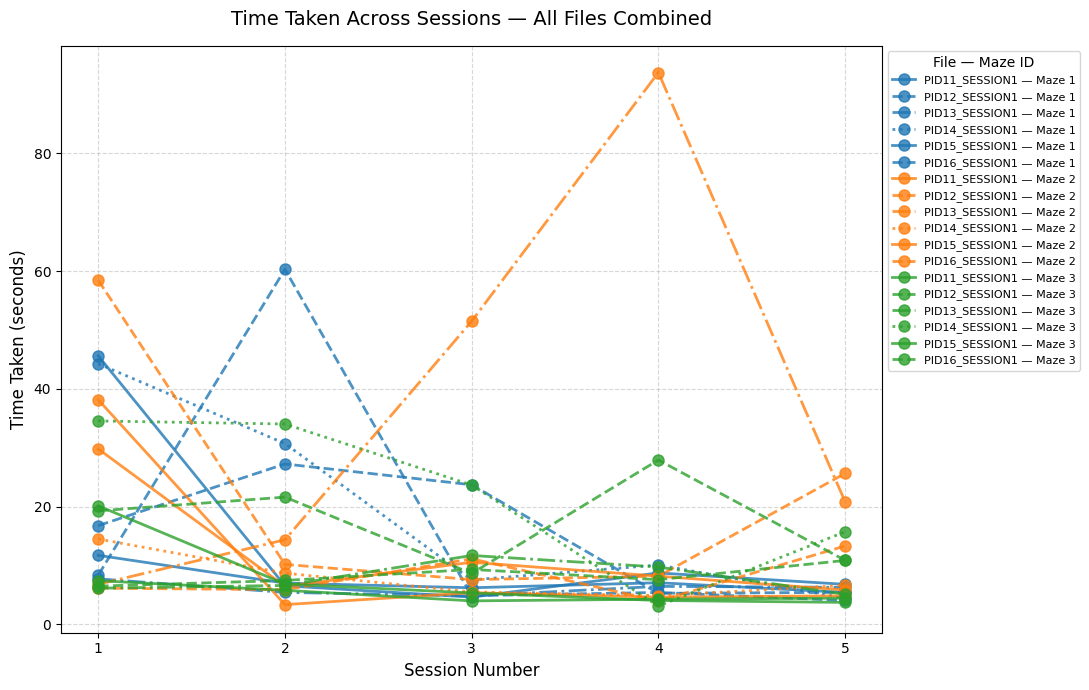

In [10]:
# Example usage
session = SessionTime(["PID11_SESSION1.csv", "PID12_SESSION1.csv", "PID13_SESSION1.csv", "PID14_SESSION1.csv", "PID15_SESSION1.csv", "PID16_SESSION1.csv"])
# One plot per file, saved into a folder
# session.plot_each_file(output_dir="per_file_plots")
# One combined comparison plot across all files
# session.plot_combined(output_file="combined_plot.png")
session.plot_combined()